# GloVe Vectors Embedding with TF 2.0 and Keras
-----------------------------------------------------------------------------
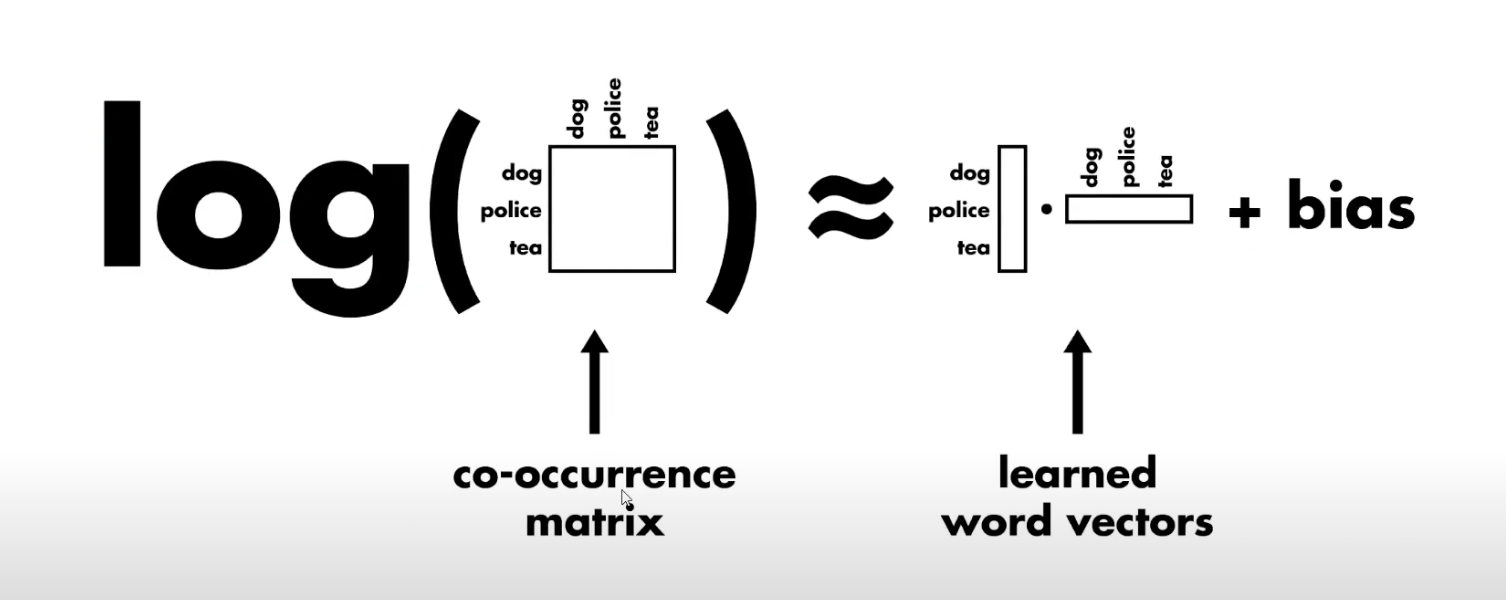
-----------------------------------------------------------------------------



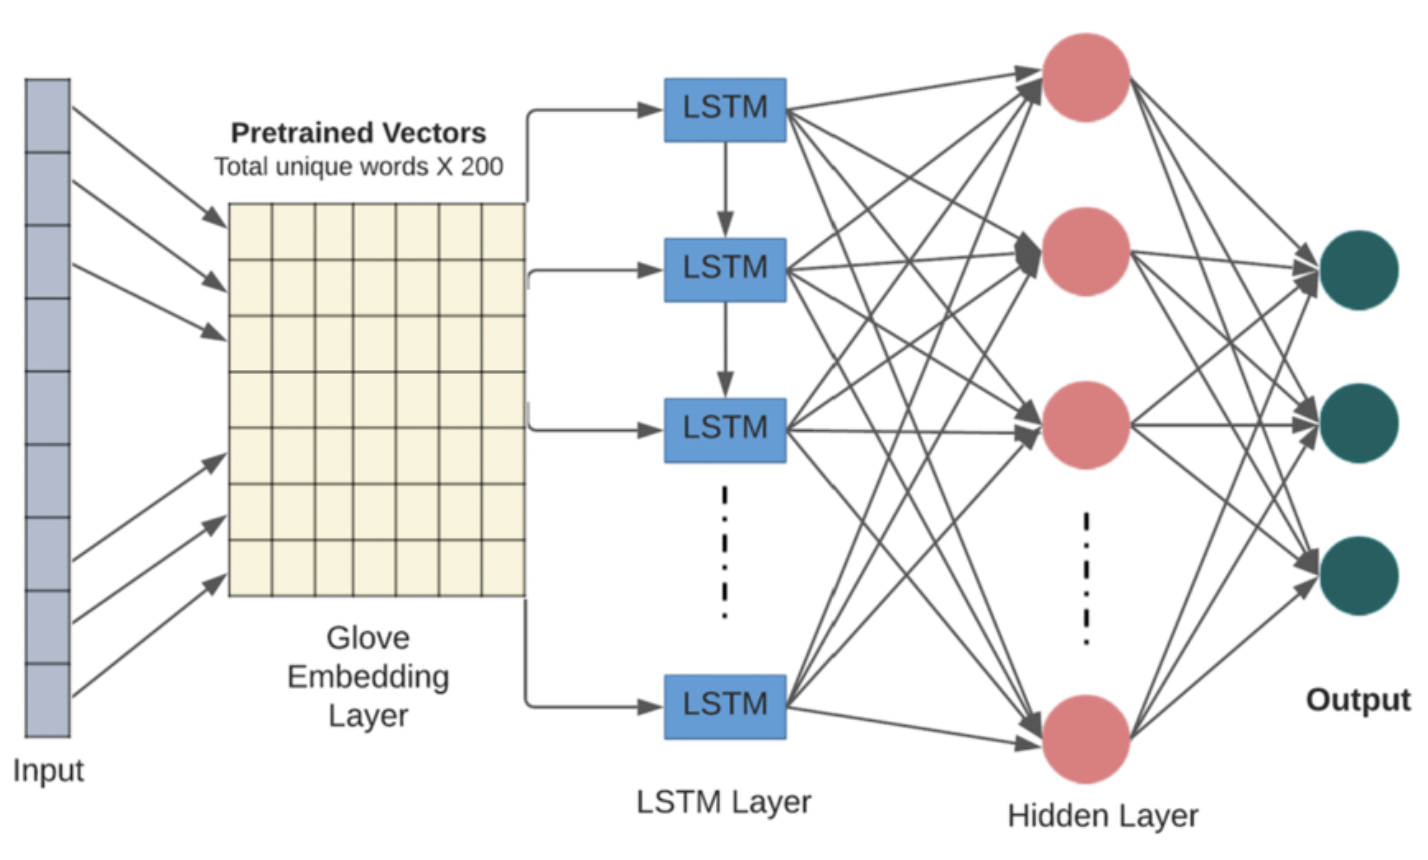

GloVe is an unsupervised learning algorithm for obtaining vector representations for words. Training is performed on aggregated global word-word co-occurrence statistics froma corpus,and the resulting representations showcase interesting linear substructuresof the word vector space

GloVe Vectors: https://nlp.stanford.edu/projects/glove/

In [159]:
from tensorflow.keras.preprocessing.text import Tokenizer, one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Flatten, Activation, Dropout
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalMaxPooling1D
import numpy as np
import pandas as pd
from numpy import asarray
from numpy import zeros
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [160]:
df = pd.read_csv('https://raw.githubusercontent.com/laxmimerit/twitter-data/refs/heads/master/twitter4000.csv')
df.head()

,twitts,sentiment
0,is bored and wants to watch a movie any sugge...,0
1,back in miami. waiting to unboard ship,0
2,"@misskpey awwww dnt dis brng bak memoriessss, ...",0
3,ughhh i am so tired blahhhhhhhhh,0
4,@mandagoforth me bad! It's funny though. Zacha...,0


## Preprocessing and Cleaning

In [161]:
contractions = {
  "ain't": "am not",
  "aren't": "are not",
  "bak": "back",
  "brng": "bring",
  "can't": "cannot",
  "can't've": "cannot have",
  "'cause": "because",
  "could've": "could have",
  "couldn't": "could not",
  "couldn't've": "could not have",
  "didn't": "did not",
  "didn't": "did not",
  "dis": "this",
  "don't": "do not",
  "hadn't": "had not",
  "hadn't've": "had not have",
  "hasn't": "has not",
  "haven't": "have not",
  "he'd": "he would",
  "he'd've": "he would have",
  "he'll": "he will",
  "he'll've": "he will have",
  "he's": "he is",
  "how'd": "how did",
  "how'd'y": "how do you",
  "how'll": "how will",
  "how's": "how is",
  "I'd": "I would",
  "I'd've": "I would have",
  "I'll": "I will",
  "I'll've": "I will have",
  "I'm": "I am",
  "I've": "I have",
  "i'm": "i am",
  "isn't": "is not",
  "it'd": "it had",
  "it'd've": "it would have",
  "it'll": "it will",
  "it'll've": "it will have",
  "it's": "it is",
  "let's": "let us",
  "ma'am": "madam",
  "mayn't": "may not",
  "might've": "might have",
  "mightn't": "might not",
  "mightn't've": "might not have",
  "must've": "must have",
  "mustn't": "must not",
  "mustn't've": "must not have",
  "needn't": "need not",
  " n ": "end",
  "needn't've": "need not have",
  "o'clock": "of the clock",
  "oughtn't": "ought not",
  "oughtn't've": "ought not have",
  "shan't": "shall not",
  "sha'n't": "shall not",
  "shan't've": "shall not have",
  "she'd": "she would",
  "she'd've": "she would have",
  "she'll": "she will",
  "she'll've": "she will have",
  "she's": "she is",
  "should've": "should have",
  "shouldn't": "should not",
  "shouldn't've": "should not have",
  "so've": "so have",
  "so's": "so is",
  "that'd": "that would",
  "that'd've": "that would have",
  "that's": "that is",
  "there'd": "there had",
  "there'd've": "there would have",
  "there's": "there is",
  "they'd": "they would",
  "they'd've": "they would have",
  "they'll": "they will",
  "they'll've": "they will have",
  "they're": "they are",
  "they've": "they have",
  "to've": "to have",
  " u ": "you",
  " ur ": "your",
  "wasn't": "was not",
  "we'd": "we had",
  "we'd've": "we would have",
  "we'll": "we will",
  "we'll've": "we will have",
  "we're": "we are",
  "we've": "we have",
  "weren't": "were not",
  "what'll": "what will",
  "what'll've": "what will have",
  "what're": "what are",
  "what's": "what is",
  "what've": "what have",
  "when's": "when is",
  "when've": "when have",
  "where'd": "where did",
  "where's": "where is",
  "where've": "where have",
  "who'll": "who will",
  "who'll've": "who will have",
  "who's": "who is",
  "who've": "who have",
  "why's": "why is",
  "why've": "why have",
  "will've": "will have",
  "won't": "will not",
  "won't've": "will not have",
  "would've": "would have",
  "wouldn't": "would not",
  "wouldn't've": "would not have",
  "y'all": "you all",
  "y'alls": "you alls",
  "y'all'd": "you all would",
  "y'all'd've": "you all would have",
  "y'all're": "you all are",
  "y'all've": "you all have",
  "you'd": "you had",
  "you'd've": "you would have",
  "you'll": "you you will",
  "you'll've": "you you will have",
  "you're": "you are",
  "you've": "you have"
}

In [162]:
%%time
import re

text = ' '.join(df['twitts'])
text = text.split()
freq_comm = pd.Series(text).value_counts()
rare = freq_comm[freq_comm.values == 1]

def get_clean_text(x):
  if type(x) is str:
    x = x.lower()
    for key in contractions:
      value = contractions[key]
      x = x.replace(key, value)
    x = re.sub(r'[a-zA-Z0-9+.-_]+@[a-zA-Z0-9+.-_]+\.[a-zA-Z0-9+.-_]+', '', x).strip() # Email cleaning
    x = re.sub(r"(http|https|ftp|ssh)://([\w_-]+(?:.[\w_-]+)+)([\w.,@?^=%&:/~+#-]*)?", '', x) # URL cleaing
    x = re.sub('RT', '', x) # RT cleaning
    x = re.sub('[^A-Z a-z]+', '', x) # nunnumeric char cleaning
    x = ' '.join([t for t in x.split() if t not in rare])
    return x
  else:
    return x

CPU times: user 21.2 ms, sys: 44 µs, total: 21.3 ms
Wall time: 22 ms


In [163]:
df['twitts'] = df['twitts'].apply(lambda x: get_clean_text(x))

In [164]:
df['twitts'].head()

,twitts
0,is bored and wants to watch a movie any sugges...
1,back in miami waiting to
2,misskpey awwww dnt this bring back memoriessss...
3,ughhh i am so tired
4,mandagoforth me bad it is funny though zachary...


In [165]:
df['sentiment'].value_counts()

,count
sentiment,
0,2000
1,2000


In [166]:
text = df['twitts'].tolist()
text[:5]

['is bored and wants to watch a movie any suggestions',
 'back in miami waiting to',
 'misskpey awwww dnt this bring back memoriessss i i am sad lol',
 'ughhh i am so tired',
 'mandagoforth me bad it is funny though zachary quinto is only there for a few though amp to reply just put the before the name']

In [167]:
y = df['sentiment']

In [168]:
token = Tokenizer()
token.fit_on_texts(text)

In [169]:
token

In [170]:
vocab_size = len(token.word_index) + 1
vocab_size

6945

In [171]:
vocab = token.index_word # unique words

for key, value in list(token.index_word.items())[:20]:
  print(f"{key}: {value}")

1: i
2: to
3: the
4: a
5: is
6: my
7: you
8: it
9: and
10: not
11: in
12: for
13: am
14: of
15: that
16: me
17: on
18: so
19: have
20: at


In [172]:
# x = [1, 2, 3, 4, 6]
x = ["i to the a and"]
token.texts_to_sequences(x)

[[1, 2, 3, 4, 9]]

In [173]:
encoded_text = token.texts_to_sequences(text)
encoded_text[:3]

[[5, 283, 9, 310, 2, 185, 4, 227, 207, 2278],
 [48, 11, 1283, 179, 2],
 [2279, 1076, 651, 29, 444, 48, 2280, 1, 1, 13, 114, 47]]

In [174]:
max_length = 120
X = pad_sequences(encoded_text, maxlen=max_length, padding='post')
X[:3]

array([[   5,  283,    9,  310,    2,  185,    4,  227,  207, 2278,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
       [  48,   11, 1283,  179,    2,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,

In [175]:
X.shape

(4000, 120)

## `GloVe` Vectors

In [176]:
glove_vectors = {}
type(glove_vectors)

dict

In [177]:
%%time

file = open('glove.twitter.27B.200d.txt', encoding='utf-8')

for line in file:
  values = line.split()
  word = values[0]
  vectors = np.asarray(values[1:], dtype='float32')
  glove_vectors[word]=vectors

file.close()

CPU times: user 1min 13s, sys: 2.93 s, total: 1min 16s
Wall time: 1min 19s


In [178]:
keys = list(glove_vectors.keys())  # Convert the keys to a list
number_to_show = 50
if len(keys) > number_to_show:
    first_keys = keys[:number_to_show]
    print(f"dict_keys({first_keys}...)")
else:
    print(f"dict_keys({keys})")

dict_keys(['<user>', '.', ':', 'rt', ',', '<repeat>', '<hashtag>', '<number>', '<url>', '!', 'i', 'a', '"', 'the', '?', 'you', 'to', '(', '<allcaps>', '<elong>', ')', 'me', 'de', '<smile>', '！', 'que', 'and', '。', '-', 'my', 'no', '、', 'is', 'it', '…', 'in', 'n', 'for', '/', 'of', 'la', "'s", '*', 'do', "n't", 'that', 'on', 'y', "'", 'e']...)


In [179]:
len(glove_vectors.keys())

1187900

In [180]:
glove_vectors.get('you')

array([ 1.9640e-01,  6.7153e-01,  6.2976e-03,  2.5359e-01, -4.2097e-01,
        3.8490e-01,  1.0378e+00, -1.8536e-01, -5.4244e-02, -1.0856e-01,
        1.2146e-01,  4.7692e-02, -9.3228e-01, -2.7192e-01, -3.5060e-01,
        1.1069e-01, -5.5099e-02, -7.9658e-02,  1.1767e-02,  1.4395e-01,
       -2.5917e-02, -1.8253e-01,  2.5691e-02,  1.9619e-01,  1.0334e-01,
        1.0731e+00,  4.1992e-01,  1.7083e-01,  9.1596e-01, -4.3398e-01,
        1.6464e-01,  1.2715e-02,  9.5477e-02,  1.4490e-01, -2.9652e-01,
       -1.0642e-01,  9.8389e-02,  1.7937e-01,  2.3289e-01, -2.2209e-01,
        8.7770e-02, -1.8005e-01,  3.8678e-01, -3.2059e-02,  1.2020e-01,
       -4.1741e-01,  2.6827e-01, -1.9769e-01,  2.1976e-02, -2.3585e-01,
        1.4789e-01,  1.0173e-01, -1.0380e-01, -3.1954e-01,  6.3308e-01,
       -5.1142e-02, -5.3209e-02,  2.9378e-01, -5.4395e-02,  4.3346e-05,
        2.5585e-01, -1.8048e-01, -2.7030e-01,  7.7783e-03,  6.3585e-01,
        1.4869e-01, -1.0854e-01, -2.4726e-01, -1.0869e-01, -2.41

In [181]:
word_vector_matrix = np.zeros((vocab_size, 200))

not_found_word_count = 0
max_not_found = 50  # Maximum number of not found words to display

for word, index in token.word_index.items():
  embedding_vector = glove_vectors.get(word)
  if embedding_vector is not None:
    word_vector_matrix[index] = embedding_vector
  else:
    if not_found_word_count < max_not_found:
      print(f"{word}             [not found in GloVe]")
      not_found_word_count += 1


tommcfly             [not found in GloVe]
dougiemcfly             [not found in GloVe]
donniewahlberg             [not found in GloVe]
thisappointed             [not found in GloVe]
kirstiealley             [not found in GloVe]
quotthe             [not found in GloVe]
peterfacinelli             [not found in GloVe]
davidarchie             [not found in GloVe]
quoti             [not found in GloVe]
thisney             [not found in GloVe]
youngq             [not found in GloVe]
jordanknight             [not found in GloVe]
atampt             [not found in GloVe]
quotyou             [not found in GloVe]
gtlt             [not found in GloVe]
songzyuuup             [not found in GloVe]
dannygokey             [not found in GloVe]
jackalltimelow             [not found in GloVe]
ashleytisdale             [not found in GloVe]
jonathanrknight             [not found in GloVe]
ughhh             [not found in GloVe]
twitterberry             [not found in GloVe]
misss             [not found in GloV

## TF2.0 and Keras Model Building

In [186]:
X[:2]

array([[   5,  283,    9,  310,    2,  185,    4,  227,  207, 2278,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
       [  48,   11, 1283,  179,    2,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,

In [187]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [188]:
vec_size = 200

model = Sequential()
model.add(Embedding(vocab_size, vec_size, input_length=max_length, weights=[word_vector_matrix], trainable=False))

model.add(Conv1D(64, 8, activation='relu'))
model.add(MaxPooling1D(2))
model.add(Dropout(0.5))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(16, activation='relu'))

model.add(GlobalMaxPooling1D())

model.add(Dense(1, activation='sigmoid'))

In [190]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
    )

In [ ]:
#X_train = X_train.astype(np.float32)
#X_test = X_test.astype(np.float32)

In [192]:
%%time
model.fit(X_train, y_train, epochs=8, validation_data=(X_test, y_test))

Epoch 1/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9613 - loss: 0.0988 - val_accuracy: 0.7325 - val_loss: 0.7673
Epoch 2/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.9710 - loss: 0.0882 - val_accuracy: 0.7375 - val_loss: 0.7749
Epoch 3/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.9563 - loss: 0.1130 - val_accuracy: 0.7350 - val_loss: 0.7511
Epoch 4/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.9570 - loss: 0.1033 - val_accuracy: 0.7387 - val_loss: 0.8144
Epoch 5/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.9641 - loss: 0.0858 - val_accuracy: 0.7325 - val_loss: 0.7668
Epoch 6/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.9669 - loss: 0.0839 - val_accuracy: 0.7262 - val_loss: 0.8103
Epoch 7/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.9688 - loss: 0.0893 - val_accuracy: 0.7350 - val_loss: 0.7726
Epoch 8/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.9623 - loss: 0.0859 - val_accurac

In [193]:
def get_encoded(x):
  x = get_clean_text(x)
  x = token.texts_to_sequences(x)
  x = pad_sequences(x, maxlen=max_length, padding='post')
  return x

In [195]:
get_encoded(["i am so happy, how about you?"])

array([[  1,  13,  18, 113,  75,  54,   7,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0]], dtype=int32)

In [196]:
x = ["worst services. will not come again"] # negative sentiment
model.predict(get_encoded(x))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


array([[0.00945891]], dtype=float32)

In [208]:
x = ["good services. i will come again"] # positive sentiment
model.predict(get_encoded(x))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


array([[0.22143592]], dtype=float32)

In [210]:
x = ["i love my job and my family very very much"] # positive sentiment
model.predict(get_encoded(x))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


array([[0.9434219]], dtype=float32)